In [109]:
import os
import pickle
import time

# DeepXDE 的 backend 必须在 import deepxde 之前设置。
# 这里使用 PyTorch backend，便于手动实现 SciANN adaptive_weights='NTK' 的梯度逻辑。
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.integrate import odeint

SEED = 1234


def set_random_seed(seed=SEED):
    """固定 NumPy、PyTorch 和 DeepXDE 的随机种子，减少两套实现之间的随机差异。"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    dde.config.set_random_seed(seed)


set_random_seed()
print("DeepXDE backend:", dde.backend.backend_name)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


DeepXDE backend: pytorch
PyTorch version: 2.12.0+cu130
CUDA available: True


## Case 1: constant trasmission rate

In [110]:
# SIR 模型，Case 1：常数传播率
# 参数 N 表示总人口，delta 表示平均感染期的倒数，r0 表示基本再生数
# beta = delta * r0，因此 r0 = beta / delta
# C 用于把 S/I/R 做尺度归一化，这里按 10^6 人口量级处理
N = 56e6  # (-) population (Italy)
delta = 1 / 5  # (1/T) 5 = mean reproduction period
r0 = 3.0  # (-) basic reproduction number (estimate for Italy)

beta = delta * r0  # (1/T) transmission rate
t0 = 0.0  # (days) initial time
tf = 90.0  # (days) final time

# 缩放因子：对应Eq. (6)
C = 1e5  # 缩放因子，按人口量级选取，便于 PINN 训练；C 的选择会影响训练稳定性和收敛速度
C1 = tf * C / N  # 对应论文 Eq. (6) 中的 C1 = tf*C/N，表示时间和人数的联合缩放因子
C2 = tf * delta  # 对应论文 Eq. (6) 中的 C2 = tf*delta，表示时间和感染期的联合缩放因子


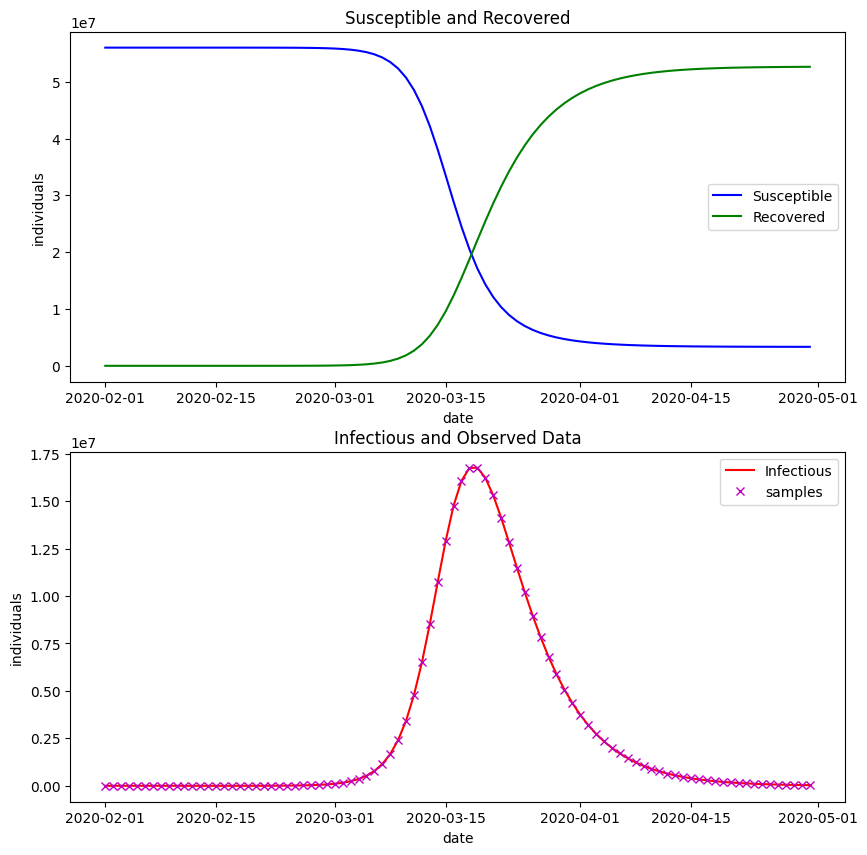

In [111]:
# 下面定义 SIR 常微分方程，对应论文 Eq. (1)-(2)
# dS/dt = -lambda*S, dI/dt = lambda*S - delta*I, dR/dt = delta*I
# lambda_val = beta * I / N，表示感染力项 beta*I/N
def SIR(x, t, delta, beta, N, t0):
    S, I, R = x
    lambda_val = beta * I / N
    dSdt = -lambda_val * S
    dIdt = lambda_val * S - delta * I
    dRdt = delta * I
    return [dSdt, dIdt, dRdt]


# Initial conditions
# 初始条件设为 S(t0)=N-I0, I(t0)=I0, R(t0)=0，对应论文 Eq. (2)
# 这里取 I0=1，表示一次初始暴发
S0 = N - 1
I0 = 1
R0 = 0
x0 = [S0, I0, R0]

# Time span
# PINN 的时间变量按 t_s = (t - t0)/(tf - t0) 归一化
timespan = np.arange("2020-02-01", "2020-05-01", dtype="datetime64[D]")
tspan = timespan.astype(int)

# 用 ODE 解生成时间序列和参考数据
# 根据 SIR 这个变化率函数，从初始值 x0 出发，数值积分得到的 S(t), I(t), R(t) 在 tspan 各个时间点上的值。
x = odeint(SIR, x0, tspan, args=(delta, beta, N, tspan[0]))

S_data = x[:, 0]
I_data = x[:, 1]
R_data = x[:, 2]

# Generate observations
# 观测数据 I_obs 是对 I_data 的泊松采样: 在固定时间段内，某类事件发生了多少次。
# 也就是说，假设 ODE 解出来的 I_data(t) 是某一天感染人数的“期望值”，真实观测到的 I_obs(t) 会围绕这个值随机波动。
I_obs = np.random.poisson(I_data)

# Plot results
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(timespan, S_data, "b", label="Susceptible")
plt.plot(timespan, R_data, "g", label="Recovered")
plt.legend()
plt.xlabel("date")
plt.ylabel("individuals")
plt.title("Susceptible and Recovered")
plt.subplot(2, 1, 2)
plt.plot(timespan, I_data, "r", label="Infectious")
plt.plot(timespan, I_obs, "xm", label="samples")
plt.legend()
plt.xlabel("date")
plt.ylabel("individuals")
plt.title("Infectious and Observed Data")
plt.show()


In [112]:
# Scale data
t_data = np.arange(t0, tf)  # 训练时间
t_test = np.arange(t0, tf, 0.1)  # 测试时间，间隔更细

# 对变量进行缩放：I_s=I/C，t_s=(t-t0)/tf，对应论文 Eq. (6)
# 这里是对 PINN 输入输出的尺度变换，便于 DeepXDE 训练
I_obs_sc = I_obs / C
I_data_sc = I_data / C
t_data_sc = t_data / tf
t_test_sc = t_test / tf

# 如果按周采样，则每 7 天取一个点
# weekly=True 时只保留每周观测，模拟稀疏数据
weekly = False
if weekly:
    I_obs_sc = I_obs_sc[::7]


In [113]:
# Training parameters
# 损失函数使用 MSE，优化器使用 Adam，并启用 NTK 自适应权重。
# DeepXDE 没有 SciANN 的 adaptive_weights={'method': 'NTK'} 接口；下面用 PyTorch autograd 手动复刻。
loss_err = "MSE"
optimizer = "adam"
learning_rate = 1e-3
adaptive_NTK = {"method": "NTK", "freq": 100}
ntk_sample_size = 100  # 与 batch_size 保持一致时，等价于 SciANN 在 data_generator[0] 上估计 NTK。


def column(values):
    """把一维数组转成 DeepXDE 约定的二维列向量。"""
    return np.asarray(values, dtype=np.float32).reshape(-1, 1)


def square_output(_, outputs):
    """DeepXDE 输出变换：对应原 SciANN 脚本的 square 输出层，保证 S_s/I_s 非负。"""
    return torch.square(outputs)


def positive_beta(beta_value):
    """DeepXDE 中的 Beta 直接对应 SciANN Parameter，并在每步后投影到非负。"""
    return torch.clamp(beta_value, min=0.0)


def tensor_to_float(value):
    """兼容 PyTorch tensor 和 NumPy 标量的取值函数，用于记录 beta。"""
    if hasattr(value, "detach"):
        value = value.detach().cpu().numpy()
    return float(np.ravel(value)[0])


def reset_deepxde_session():
    """重置 DeepXDE backend 会话；PyTorch backend 下通常没有需要清理的全局图。"""
    if hasattr(dde.backend, "clear_session"):
        dde.backend.clear_session()


def print_model_device(name, model):
    """打印 DeepXDE 模型网络参数所在设备。"""
    if dde.backend.backend_name == "pytorch":
        print(f"{name} network device:", next(model.net.parameters()).device)


def initialize_sciann_like(net):
    """近似 SciANN/Keras 默认初始化：权重截断正态，bias 小范围均匀。"""
    linear_index = 0
    for module in net.modules():
        if not isinstance(module, torch.nn.Linear):
            continue
        fan_in, fan_out = torch.nn.init._calculate_fan_in_and_fan_out(module.weight)
        denominator = fan_in if linear_index == 0 else (fan_in + fan_out) / 2.0
        stddev = np.sqrt(1.0 / denominator) / 0.87962566103423978
        torch.nn.init.trunc_normal_(module.weight, mean=0.0, std=stddev, a=-2.0 * stddev, b=2.0 * stddev)
        torch.nn.init.uniform_(module.bias, a=-0.05, b=0.05)
        linear_index += 1


def sciann_training_steps(num_samples, epochs, batch_size):
    """把 SciANN 的 epochs/batch_size 语义换算成 DeepXDE 的 optimizer update 次数。"""
    steps_per_epoch = int(np.ceil(num_samples / batch_size))
    return epochs * steps_per_epoch


def zero_like_loss(error):
    """返回一个保持梯度图连接的零损失，用于复刻 SciANN 中的零占位项。"""
    return torch.mean(torch.square(error * 0.0))


def relative_l2(reference, prediction):
    """计算相对 L2 误差：||u-u_hat||_2 / ||u||_2。"""
    reference = np.ravel(reference)
    prediction = np.ravel(prediction)
    return np.linalg.norm(reference - prediction, 2) / np.linalg.norm(reference, 2)


class DeepXDEFunctional:
    """给 DeepXDE 网络输出提供 SciANN Functional 风格的 eval(model, t) 接口。"""

    def __init__(self, name, component=None, expression=None):
        self.name = name
        self.component = component
        self.expression = expression

    def eval(self, model, t_points):
        pred = model.predict(column(t_points))
        if self.expression == "N/C-Is-Ss":
            return N / C - pred[:, 1:2] - pred[:, 0:1]
        return pred[:, self.component : self.component + 1]


class DeepXDEParameter:
    """给 DeepXDE 外部可训练变量提供 SciANN Parameter 风格的 eval(model, t) 接口。"""

    def __init__(self, name, variable):
        self.name = name
        self.variable = variable

    def eval(self, model, t_points):
        value = tensor_to_float(positive_beta(self.variable))
        return np.full((column(t_points).shape[0], 1), value, dtype=np.float32)


class SciANNStyleBatchData(dde.data.Data):
    """用 SciANN 的 y_true/sample_weight 语义组织 DeepXDE mini-batch 训练数据。"""

    def __init__(self, train_x, loss_targets, output_fn, batch_size=100, shuffle=True):
        self.train_x_all = column(train_x)
        self.loss_targets = self.prepare_targets(loss_targets)
        self.output_fn = output_fn
        self.batch_size = batch_size
        self.train_sampler = dde.data.BatchSampler(len(self.train_x_all), shuffle=shuffle)
        self._train_indices = np.arange(len(self.train_x_all))
        self._test_indices = np.arange(len(self.train_x_all))
        self.train_x = self.train_x_all
        self.test_x = self.train_x_all
        self.train_aux_vars = None
        self.test_aux_vars = None

    def prepare_targets(self, loss_targets):
        prepared = []
        for target_spec in loss_targets:
            if target_spec in ("zeros", "zero_placeholder"):
                prepared.append(target_spec)
                continue
            ids, values = target_spec
            ids = np.asarray(ids, dtype=np.intp)
            full_values = np.zeros((len(self.train_x_all), 1), dtype=np.float32)
            full_weights = np.zeros((len(self.train_x_all), 1), dtype=np.float32)
            full_values[ids] = column(values)
            full_weights[ids] = 1.0
            prepared.append({"values": full_values, "weights": full_weights})
        return prepared

    def train_next_batch(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_size
        self._train_indices = self.train_sampler.get_next(batch_size)
        self.train_x = self.train_x_all[self._train_indices]
        return self.train_x, None, None

    def test(self):
        self._test_indices = np.arange(len(self.train_x_all))
        self.test_x = self.train_x_all
        return self.test_x, None, None

    def losses_for_indices(self, indices, outputs, loss_fn, inputs):
        loss_outputs = self.output_fn(inputs, outputs)
        losses = []
        for output, target_spec in zip(loss_outputs, self.loss_targets):
            if target_spec == "zeros":
                losses.append(loss_fn(torch.zeros_like(output), output))
            elif target_spec == "zero_placeholder":
                losses.append(zero_like_loss(output))
            else:
                target = torch.as_tensor(target_spec["values"][indices], dtype=output.dtype, device=output.device)
                weights = torch.as_tensor(target_spec["weights"][indices], dtype=output.dtype, device=output.device)
                losses.append(loss_fn(target * weights, output * weights))
        return losses

    def losses_train(self, targets, outputs, loss_fn, inputs, model, aux=None):
        return self.losses_for_indices(self._train_indices, outputs, loss_fn, inputs)

    def losses_test(self, targets, outputs, loss_fn, inputs, model, aux=None):
        return self.losses_for_indices(self._test_indices, outputs, loss_fn, inputs)

    def losses(self, targets, outputs, loss_fn, inputs, model, aux=None):
        return self.losses_train(targets, outputs, loss_fn, inputs, model, aux=aux)


class BetaLogger(dde.callbacks.Callback):
    """记录 DeepXDE 外部可训练变量 Beta 的训练轨迹。"""

    def __init__(self, beta_raw, period=1):
        super().__init__()
        self.beta_raw = beta_raw
        self.period = period
        self.values = []

    def on_epoch_end(self):
        step = self.model.train_state.step
        if step % self.period == 0:
            self.values.append(tensor_to_float(positive_beta(self.beta_raw)))


class NonNegativeParameter(dde.callbacks.Callback):
    """模拟 SciANN Parameter(non_neg=True)：每次优化后把参数投影到非负半轴。"""

    def __init__(self, *parameters):
        super().__init__()
        self.parameters = parameters

    def on_batch_end(self):
        with torch.no_grad():
            for parameter in self.parameters:
                parameter.clamp_(min=0.0)


class NTKAdaptiveWeights(dde.callbacks.Callback):
    """按 SciANN NTKLossWeight 的 active 实现动态平衡 DeepXDE 的多项损失。"""

    def __init__(self, freq=100, beta=0.9, alpha=0.0, min_max=None, sample_size=None, eps=1e-12):
        super().__init__()
        self.freq = np.inf if freq in (False, 0) else freq
        self.beta = beta
        self.alpha = alpha
        self.min_max = [-np.inf, np.inf] if min_max is None else min_max
        self.sample_size = sample_size
        self.eps = eps
        self.values = []
        self.loss_gradients = []
        self.diag_ntk_history = []
        self.ntk_shapes = []
        self.base_losses = None
        self.ntk_x = None
        self.ntk_indices = None

    def on_train_begin(self):
        # SciANN 的 NTKLossWeight 在 callback 初始化时固定 data_generator[0]。
        # 这里在 DeepXDE 首次 train_next_batch 后捕获同一个语义的第一批点，之后每次更新都复用这批点。
        self.ntk_x = self.as_model_tensor(self.model.train_state.X_train).detach()
        self.ntk_indices = np.asarray(self.model.data._train_indices, dtype=np.intp).copy()
        if self.alpha > 0:
            self.base_losses = self.current_unweighted_losses()
        self.update_weights()

    def on_epoch_begin(self):
        step = self.model.train_state.step
        if step > 0 and step % self.freq == 0:
            self.update_weights()

    def trainable_parameters(self):
        parameters = [p for p in self.model.net.parameters() if p.requires_grad]
        parameters.extend(self.model.external_trainable_variables)
        return parameters

    def model_device(self):
        return next(self.model.net.parameters()).device

    def model_dtype(self):
        return next(self.model.net.parameters()).dtype

    def as_model_tensor(self, values):
        return torch.as_tensor(values, dtype=self.model_dtype(), device=self.model_device())

    def input_tensor(self, x_value):
        return self.as_model_tensor(x_value).reshape(1, -1).requires_grad_()

    def loss_outputs(self, x_tensor):
        y = self.model.net(x_tensor)
        return self.model.data.output_fn(x_tensor, y)

    def squared_grad_norm(self, output):
        parameters = self.trainable_parameters()
        grads = torch.autograd.grad(torch.sum(output), parameters, retain_graph=True, allow_unused=True)
        trace = torch.zeros((), dtype=output.dtype, device=output.device)
        for grad_item in grads:
            if grad_item is not None:
                trace = trace + torch.sum(torch.square(grad_item.detach()))
        return trace.detach()

    def clear_gradients(self):
        if hasattr(dde.grad, "clear"):
            dde.grad.clear()
        if hasattr(self.model, "opt"):
            self.model.opt.zero_grad(set_to_none=True)

    def selected_local_indices(self):
        n_points = int(self.ntk_x.shape[0])
        if self.sample_size is None or n_points <= self.sample_size:
            return np.arange(n_points, dtype=np.intp)
        return np.linspace(0, n_points - 1, self.sample_size).astype(np.intp)

    def eval_diag_ntk(self):
        # 对第 k 个 loss 项，J_k 的行是 residual/output_k(x_i) 对全部可训练参数的梯度。
        # 完整 NTK 为 K_k = J_k @ J_k.T，维度是 active_points_k x active_points_k。
        # SciANN 当前实现只使用 diag(K_k)，即每个样本梯度范数平方；这里保持同样语义。
        local_indices = self.selected_local_indices()
        num_terms = len(self.loss_outputs(self.input_tensor(self.ntk_x[local_indices[0]])))
        diag_ntk = torch.zeros((num_terms, len(local_indices)), dtype=self.model_dtype(), device=self.model_device())
        ntk_shapes = []

        for col, local_index in enumerate(local_indices):
            global_index = int(self.ntk_indices[local_index])
            x_tensor = self.input_tensor(self.ntk_x[local_index])
            outputs = self.loss_outputs(x_tensor)
            for term_index, output in enumerate(outputs):
                target_spec = self.model.data.loss_targets[term_index]
                if isinstance(target_spec, dict) and target_spec["weights"][global_index, 0] == 0.0:
                    continue
                diag_ntk[term_index, col] = self.squared_grad_norm(output)
            self.clear_gradients()

        selected_global_indices = self.ntk_indices[local_indices]
        for term_index, target_spec in enumerate(self.model.data.loss_targets):
            if isinstance(target_spec, dict):
                active_count = int(np.sum(target_spec["weights"][selected_global_indices, 0] != 0.0))
            else:
                active_count = len(local_indices)
            ntk_shapes.append((active_count, active_count))
        self.ntk_shapes.append(ntk_shapes)
        return diag_ntk

    def current_unweighted_losses(self):
        previous_weights = self.model.loss_weights
        self.model.loss_weights = None
        losses = self.model.outputs_losses_train(
            self.model.train_state.X_train,
            self.model.train_state.y_train,
            self.model.train_state.train_aux_vars,
        )[1]
        self.model.loss_weights = previous_weights
        return losses.detach()

    def update_weights(self):
        diag_ntk = self.eval_diag_ntk()
        traces = torch.sum(diag_ntk, dim=1)
        normalization_grad = torch.sum(traces)

        if normalization_grad <= self.eps:
            ntk_weights = torch.ones_like(traces)
        else:
            mean_trace = torch.mean(traces)
            denom = torch.where(traces > self.eps, traces, mean_trace + self.eps)
            ntk_weights = normalization_grad / denom

        if self.base_losses is not None:
            losses = self.current_unweighted_losses()
            scores = losses / self.base_losses
            scores = torch.pow(scores / torch.mean(scores), self.alpha)
            ntk_weights = ntk_weights * scores

        ntk_weights = torch.clamp(ntk_weights, min=self.min_max[0], max=self.min_max[1])
        ntk_weights = ntk_weights * (ntk_weights.numel() / torch.sum(ntk_weights))

        old_weights = self.as_model_tensor(self.model.loss_weights)
        new_weights = (1.0 - self.beta) * old_weights + self.beta * ntk_weights
        new_weights_np = new_weights.detach().cpu().numpy()

        self.model.loss_weights = new_weights_np.tolist()
        self.values.append(new_weights_np)
        self.diag_ntk_history.append(diag_ntk.detach().cpu().numpy())
        self.loss_gradients.append(np.linalg.norm(self.diag_ntk_history[-1], axis=1))
        self.clear_gradients()
        print("adaptive_weights:", self.model.loss_weights)


def make_deepxde_history(losshistory, beta_logger=None, ntk_logger=None):
    """把 DeepXDE LossHistory 整理成近似 SciANN h.history 的字典。"""
    history = {
        "steps": np.asarray(losshistory.steps),
        "loss_train": np.asarray(losshistory.loss_train),
        "loss_test": np.asarray(losshistory.loss_test),
    }
    if beta_logger is not None:
        history["Beta"] = np.asarray(beta_logger.values)
    if ntk_logger is not None:
        history["loss_weights"] = np.asarray(ntk_logger.values)
        history["loss_gradients"] = np.asarray(ntk_logger.loss_gradients)
        history["diag_ntk"] = np.asarray(ntk_logger.diag_ntk_history)
        history["ntk_shapes"] = ntk_logger.ntk_shapes
    return history


class DeepXDEHistory:
    """提供 h.history 字段，方便后续 cell 沿用原 SciANN notebook 的变量名。"""

    def __init__(self, losshistory, beta_logger=None, ntk_logger=None):
        self.history = make_deepxde_history(losshistory, beta_logger, ntk_logger)


### Joint

In [114]:
reset_deepxde_session()


In [115]:
# Build NN - Joint
# 构建神经网络 - joint 方法，同时学习 S、I 和 beta_s（对应论文 Section 2.2）

# ts 是归一化时间变量名；DeepXDE 在 data 对象中接收具体的 t_train 数组。
# 原 SciANN 的 Variable 没有一一对应对象，因此这里保留变量名用于注释和 residual 函数语义。
ts = "ts"

# 两个神经网络分别拟合 S_s 和 I_s，输出层使用 square 变换保证非负；网络结构为 4 层、每层 50 个神经元。
# DeepXDE 的 PFNN 使用两个并行子网络，对应原来的 Ss 和 Is 两个 Functional。
net_joint = dde.nn.PFNN([1, [50, 50], [50, 50], [50, 50], [50, 50], [1, 1]], "tanh", "Glorot uniform")
initialize_sciann_like(net_joint)
net_joint.apply_output_transform(square_output)

Ss = DeepXDEFunctional("Ss", component=0)
Is = DeepXDEFunctional("Is", component=1)

# Beta 是待识别的传播率参数 beta_s_hat(ts)，这里设为非负常数参数。
# DeepXDE 用外部可训练变量表示常数参数；NonNegativeParameter 回调负责非负投影。
Beta_raw = dde.Variable(np.float32(1.0))
Beta = DeepXDEParameter("Beta", Beta_raw)

# 根据守恒关系计算 R_s（对应论文中的 N=S+I+R）
# 即 R_s = N/C - I_s - S_s，用缩放后的变量保持总量守恒。
Rs = DeepXDEFunctional("Rs", expression="N/C-Is-Ss")


In [116]:
# Initial Conditions
# 用 sign 符号函数构造 t=t0 处的初始条件约束（对应论文 Eq. (9)）。
# DeepXDE residual 在 loss_joint_outputs 中定义，变量名 L_* 与原 SciANN notebook 保持一致。
L_S0 = "L_S0"
L_I0 = "L_I0"
L_R0 = "L_R0"

# ODEs
# ODE 残差使用缩放后的 S/I/R 变量（对应论文 Eq. (8)）。
L_dSdt = "L_dSdt"
L_dIdt = "L_dIdt"
L_dRdt = "L_dRdt"


def loss_joint_outputs(ts_tensor, y):
    """DeepXDE/PyTorch 版 residual；返回顺序与 loss_joint 完全一致。"""
    Ss_value = y[:, 0:1]
    Is_value = y[:, 1:2]
    Rs_value = N / C - Is_value - Ss_value

    dSs_dts = dde.grad.jacobian(y, ts_tensor, i=0, j=0)
    dIs_dts = dde.grad.jacobian(y, ts_tensor, i=1, j=0)
    dRs_dts = -dSs_dts - dIs_dts

    initial_mask = 1.0 - torch.sign(ts_tensor - t0 / tf)
    Beta_value = positive_beta(Beta.variable)

    L_dSdt_value = dSs_dts + C1 * Beta_value * Is_value * Ss_value
    L_dIdt_value = dIs_dts - C1 * Beta_value * Is_value * Ss_value + C2 * Is_value
    L_dRdt_value = dRs_dts - C2 * Is_value
    L_S0_value = (Ss_value - S0 / C) * initial_mask
    L_I0_value = (Is_value - I0 / C) * initial_mask
    L_R0_value = (Rs_value - R0 / C) * initial_mask

    return [
        L_dSdt_value,
        L_dIdt_value,
        L_dRdt_value,
        L_S0_value,
        L_I0_value,
        L_R0_value,
        Ss_value * 0.0,
        Rs_value * 0.0,
        Is_value,
    ]


In [117]:
# Build the model - Joint
# 构建 joint 模型的损失函数，包含 ODE 残差、初始条件和数据项（对应论文 Eq. (10)）
# 整体形式为 L_joint =  L_ODE + L_IC + L_D
# 最后的 Is 用观测感染人数约束 I_s 的预测值。
loss_joint = [
    L_dSdt,
    L_dIdt,
    L_dRdt,
    L_S0,
    L_I0,
    L_R0,
    "Data(Ss*0.0)",
    "Data(Rs*0.0)",
    "Data(Is)",
]

# DeepXDE 的 dde.Model 需要先拿到 Data 对象；Data 又依赖下一 cell 中的 t_train/loss_train。
# 因此这里先保留 loss_joint，实际 m = dde.Model(...) 在训练点 cell 末尾完成。
m = None


In [ ]:
# Training points
# 组织训练数据和随机 collocation 点
# 前半部分使用 I_obs 观测数据，后半部分用于 ODE 物理残差约束
Nc = 6000  # collocation points
I_obs_sc = I_obs_sc.reshape(-1, 1)  # 观测数据 I_s 的训练目标

# 时间采样密度偏向早期时间，增加 t=0 附近的采样点密度，有助于 PINN 更好地拟合初始阶段的数据和满足物理约束
#   np.log1p / np.exp 用于在 [0, tf] 上生成更偏向早期时间的采样点
#   具体来说所以 t=0 附近的密度比 t=1 附近大约高一倍，时间范围没有改变
t_train_ode = np.random.uniform(np.log1p(t0 / tf), np.log1p(1.0), Nc)  # 在 [log1p(t0/tf), log1p(1)] 上生成 Nc 个随机数，偏向早期时间
t_train_ode = np.exp(t_train_ode) - 1.0  # 反变换回 [t0/tf, 1]，得到 ODE 约束的训练时间点

# 将观测数据点和 ODE 约束点合并成训练时间 t_train；ids_data 用于标记哪些点对应观测数据，便于后续构建损失函数
if weekly:
    t_train = np.concatenate([t_data_sc[::7].reshape(-1, 1), t_train_ode.reshape(-1, 1)])
    ids_data = np.arange(t_data_sc[::7].size, dtype=np.intp)
else:
    t_train = np.concatenate([t_data_sc.reshape(-1, 1), t_train_ode.reshape(-1, 1)])
    ids_data = np.arange(t_data_sc.size, dtype=np.intp)

# loss_train 是训练目标。这里用自定义 Data 复刻 SciANN 的 y_true/sample_weight 语义。
#   0:3 对应 ODE 残差项
#   3:6 对应初始条件约束
#   6:8 对应 S_s 和 R_s 的零占位数据项
#   8 表示 I_s 的数据约束，只在 ids_data 对应观测点上生效
loss_train = ["zeros"] * 8 + [(ids_data, I_obs_sc)]
epochs_joint = 5000
batch_size = 100
iterations_joint = sciann_training_steps(t_train.shape[0], epochs_joint, batch_size)

# log_params 用于记录训练过程中参数的变化；DeepXDE 版由 BetaLogger 完成，保留变量名便于和原 notebook 对照。
log_params = {"parameters": Beta, "freq": 1}

# DeepXDE 需要在已知训练点后创建 Data 和 Model；这是与 SciANN 建模顺序不同的地方。
data_joint = SciANNStyleBatchData(t_train, loss_train, loss_joint_outputs, batch_size=batch_size)
beta_logger_joint = BetaLogger(Beta.variable, period=log_params["freq"])
ntk_logger_joint = NTKAdaptiveWeights(freq=adaptive_NTK["freq"], sample_size=ntk_sample_size)
nonnegative_joint = NonNegativeParameter(Beta.variable)

m = dde.Model(data_joint, net_joint)  # DeepXDE 的 Model 对应 SciANN 的 SciModel
m.compile(
    optimizer,
    lr=learning_rate,
    loss=loss_err,
    loss_weights=[1.0] * len(loss_joint),
    external_trainable_variables=[Beta.variable],
)
print_model_device("Joint", m)


Compiling model...
'compile' took 0.000628 s

Joint network device: cuda:0


In [ ]:
# Train the model
# 训练 joint 模型，并记录训练耗时

time1 = time.time()
losshistory, train_state = m.train(
    iterations=iterations_joint,
    batch_size=batch_size,
    callbacks=[nonnegative_joint, beta_logger_joint, ntk_logger_joint],  # BetaLogger 对应原 log_parameters；NTKAdaptiveWeights 对应 adaptive_weights
    display_every=100,
    verbose=1,
)
h = DeepXDEHistory(losshistory, beta_logger_joint, ntk_logger_joint)
time2 = time.time()


Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [2.42e-02, 1.11e-01, 1.60e-01, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 3.80e-03]    [2.69e-02, 9.48e-02, 1.42e-01, 5.15e+01, 1.64e-08, 5.15e+01, 0.00e+00, 0.00e+00, 4.76e+01]    []  
adaptive_weights: [0.10557439923286438, 0.1008063554763794, 0.10070376098155975, 0.10316835343837738, 0.10316835343837738, 0.10316835343837738, 0.10316835343837738, 0.10316835343837738, 8.17707347869873]
100       [2.11e-02, 1.15e-02, 3.25e-03, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.25e+01]    [1.90e-02, 1.11e-02, 3.16e-03, 5.30e+00, 3.01e-09, 5.30e+00, 0.00e+00, 0.00e+00, 3.89e+02]    []  
adaptive_weights: [0.011125356890261173, 0.010455352254211903, 0.010295284911990166, 0.011330820620059967, 0.011330820620059967, 0.011330820620059967, 0.01133082

In [120]:
print(f"Training time: {time2 - time1}")


Training time: 126.91298174858093


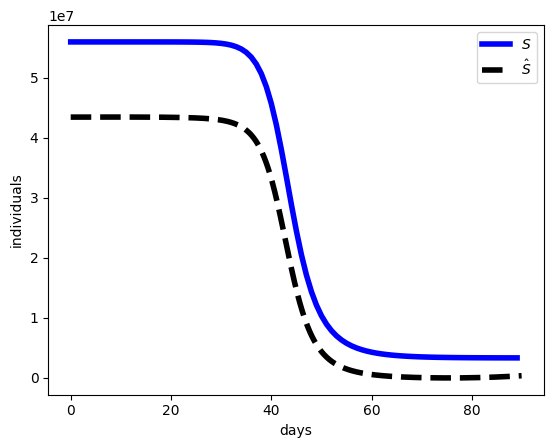

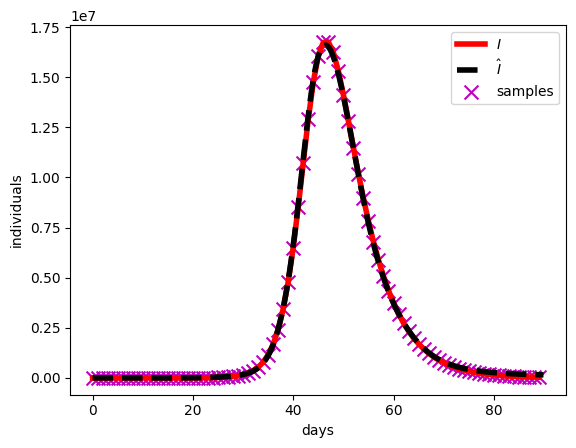

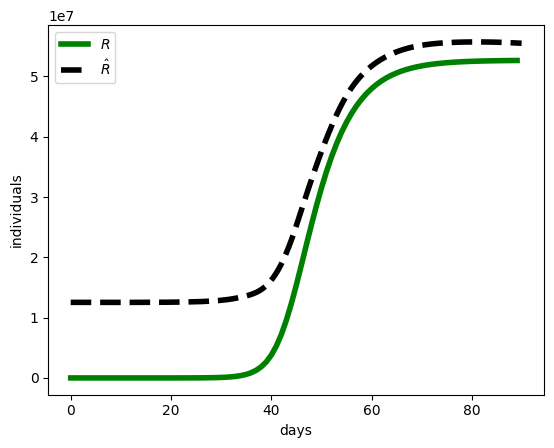

In [121]:
# Get predictions
# 获取 joint 模型在测试时间上的 S/I/R 预测结果
# 预测值仍是缩放变量，绘图时乘以 C 还原到人数尺度
S_pred_test = Ss.eval(m, t_test_sc)
I_pred_test = Is.eval(m, t_test_sc)
R_pred_test = Rs.eval(m, t_test_sc)

# Plot results
plt.plot(t_data, S_data, c="b", linewidth=4)
plt.plot(t_test, S_pred_test * C, "--", c="k", linewidth=4)
plt.xlabel("days")
plt.ylabel("individuals")
plt.legend(["$S$", "$\hat{S}$"])
plt.show()

plt.plot(t_data, I_data, c="r", linewidth=4)
plt.plot(t_test, I_pred_test * C, "--", c="k", linewidth=4)
if weekly:
    plt.scatter(t_data[::7], I_obs[::7], marker="x", c="m", s=100)
else:
    plt.scatter(t_data, I_obs, marker="x", c="m", s=100)
plt.xlabel("days")
plt.ylabel("individuals")
plt.legend(["$I$", "$\hat{I}$", "samples"])
plt.show()

plt.plot(t_data, R_data, c="g", linewidth=4)
plt.plot(t_test, R_pred_test * C, "--", c="k", linewidth=4)
plt.xlabel("days")
plt.ylabel("individuals")
plt.legend(["$R$", "$\hat{R}$"])
plt.show()


In [122]:
# Evaluate errors
# 计算相对 L2 误差，并评估 Beta 的识别误差
# 相对误差形式为 ||u-u_hat||_2 / ||u||_2；Beta 在本 case 中是常数，因此取 beta_pred[0]
S_pred = Ss.eval(m, t_data_sc).ravel() * C
I_pred = Is.eval(m, t_data_sc).ravel() * C
R_pred = Rs.eval(m, t_data_sc).ravel() * C
beta_pred = Beta.eval(m, t_data_sc)

S_err = relative_l2(S_data, S_pred)
I_err = relative_l2(I_data, I_pred)
R_err = relative_l2(R_data, R_pred)
beta_err = abs(float(np.ravel(beta_pred)[0]) - beta) / beta

print(f"S error: {S_err:.3e}")
print(f"I error: {I_err:.3e}")
print(f"R error: {R_err:.3e}")
print(f"Beta error: {beta_err:.3e}")


S error: 2.453e-01
I error: 1.396e-02
R error: 2.826e-01
Beta error: 5.012e-01


In [123]:
# Save training history and model
# 保存 joint 阶段的训练历史和模型权重
# h.history 包含 loss、Beta、NTK adaptive weights、diag-NTK 和每个 loss 项的 NTK 维度记录。
with open("hJoint.txt", "wb") as myFile:
    pickle.dump(h.history, myFile)
myFile.close()

# DeepXDE/PyTorch 使用 model.save 保存 checkpoint；这是 SciANN m.save_weights('mJoint.hdf5') 的对应替换。
m.save("mJoint", verbose=0)


'mJoint-5000.pt'